## Setup and Installation

In [1]:
print("=" * 60)
print("CodeBridge Training Environment Setup")
print("=" * 60)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import random
import pickle
import os
import zipfile
import shutil
from tqdm import tqdm
from datetime import datetime
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")
print("=" * 60)

CodeBridge Training Environment Setup
PyTorch version: 2.9.0+cu126
Device: cuda
 GPU: NVIDIA A100-SXM4-40GB


## Synthetic Data Generator

In [2]:
print("\n Generating Synthetic Training Data...")

class SyntheticDataGenerator:
    def __init__(self, seed=42):
        random.seed(seed)

        self.entities = ['User', 'Payment', 'Order', 'Product', 'Customer',
                        'Invoice', 'Cart', 'Transaction', 'Account']
        self.fields = ['id', 'email', 'amount', 'status', 'total', 'name', 'price']
        self.operations = ['create', 'update', 'delete', 'validate', 'process']

    def generate_javascript(self, count=1000):
        samples = []
        for _ in range(count):
            entity = random.choice(self.entities)
            field = random.choice(self.fields)
            operation = random.choice(self.operations)

            code = f"""function {operation}{entity}(data) {{
    if (!data.{field}) {{
        return {{ error: '{field} required' }};
    }}
    return fetch('/api/{entity.lower()}', {{
        method: 'POST',
        body: JSON.stringify(data)
    }});
}}"""

            explanation = f"Function to {operation} {entity.lower()} by validating {field} field and sending POST request to API endpoint"

            samples.append({
                'language': 'javascript',
                'code': code,
                'explanation': explanation
            })
        return samples

    def generate_java(self, count=1000):
        samples = []
        for _ in range(count):
            entity = random.choice(self.entities)
            operation = random.choice(self.operations)

            code = f"""@PostMapping("/api/{entity.lower()}")
public ResponseEntity<{entity}> {operation}{entity}(@RequestBody {entity} request) {{
    if (request == null) {{
        return ResponseEntity.badRequest().build();
    }}
    {entity} result = service.{operation}(request);
    return ResponseEntity.ok(result);
}}"""

            explanation = f"REST endpoint to {operation} {entity.lower()} with request validation and service delegation"

            samples.append({
                'language': 'java',
                'code': code,
                'explanation': explanation
            })
        return samples

    def generate_sql(self, count=1000):
        samples = []
        for _ in range(count):
            entity = random.choice(self.entities)
            operation = random.choice(['insert', 'update', 'select'])
            field1 = random.choice(self.fields)
            field2 = random.choice(self.fields)

            if operation == 'insert':
                code = f"""INSERT INTO {entity}s ({field1}, {field2}, created_at)
VALUES (@{field1}, @{field2}, GETDATE());"""
            elif operation == 'update':
                code = f"""UPDATE {entity}s
SET {field1} = @{field1}, updated_at = GETDATE()
WHERE {field2} = @{field2};"""
            else:
                code = f"""SELECT {field1}, {field2}, created_at
FROM {entity}s
WHERE {field1} IS NOT NULL
ORDER BY created_at DESC;"""

            explanation = f"SQL query to {operation} {entity.lower()} records with {field1} and {field2} fields"

            samples.append({
                'language': 'sql',
                'code': code,
                'explanation': explanation
            })
        return samples

    def generate_dataset(self, train_size=3000, val_size=500, test_size=100):
        # Generate samples for each language
        js_train = self.generate_javascript(train_size // 3)
        java_train = self.generate_java(train_size // 3)
        sql_train = self.generate_sql(train_size // 3)

        js_val = self.generate_javascript(val_size // 3)
        java_val = self.generate_java(val_size // 3)
        sql_val = self.generate_sql(val_size // 3)

        js_test = self.generate_javascript(test_size // 3)
        java_test = self.generate_java(test_size // 3)
        sql_test = self.generate_sql(test_size // 3)

        train_data = js_train + java_train + sql_train
        val_data = js_val + java_val + sql_val
        test_data = js_test + java_test + sql_test

        random.shuffle(train_data)
        random.shuffle(val_data)
        random.shuffle(test_data)

        return train_data, val_data, test_data

generator = SyntheticDataGenerator()
train_data, val_data, test_data = generator.generate_dataset(train_size=3000, val_size=500, test_size=100)

print(f"Generated {len(train_data)} training samples")
print(f"Generated {len(val_data)} validation samples")
print(f"Generated {len(test_data)} test samples")

with open('train_data.json', 'w') as f:
    json.dump(train_data, f)
with open('val_data.json', 'w') as f:
    json.dump(val_data, f)
with open('test_data.json', 'w') as f:
    json.dump(test_data, f)


 Generating Synthetic Training Data...
Generated 3000 training samples
Generated 498 validation samples
Generated 99 test samples


## Data Visualization


 Visualizing Dataset Distribution...


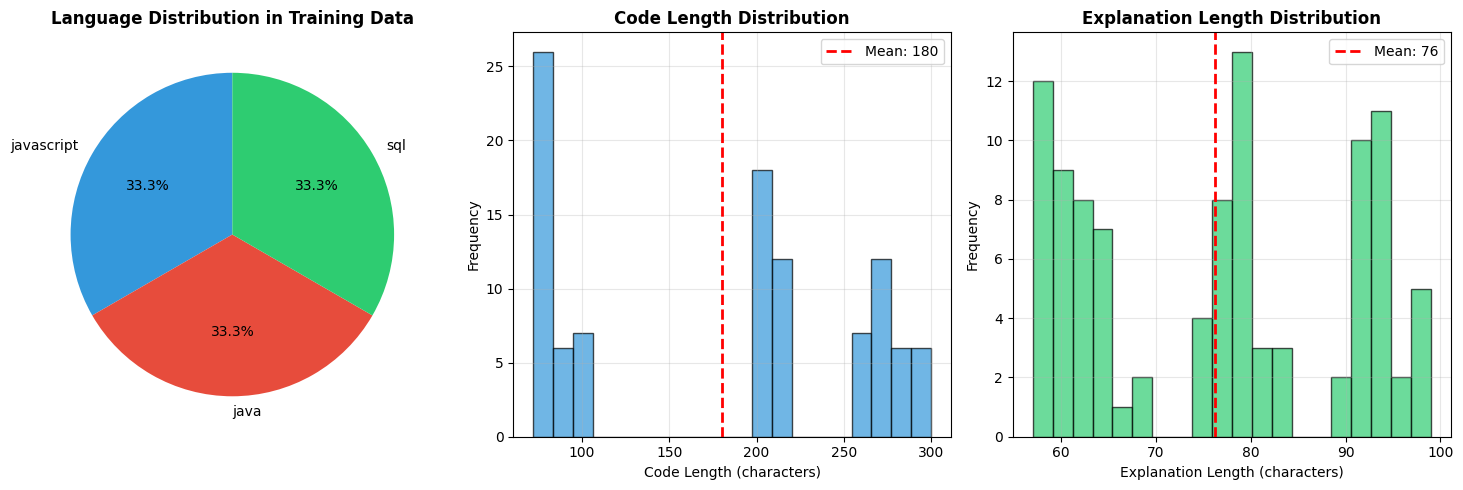


 Dataset Statistics:
  Total samples: 3597
  Training: 3000 | Validation: 498 | Test: 99
  Languages: javascript, java, sql
  Avg code length: 180 chars
  Avg explanation length: 76 chars
  Samples per language: javascript: 1000, java: 1000, sql: 1000


In [3]:
print("\n Visualizing Dataset Distribution...")

languages = {}
for item in train_data:
    lang = item['language']
    languages[lang] = languages.get(lang, 0) + 1

code_lengths = [len(item['code']) for item in train_data[:100]]
explanation_lengths = [len(item['explanation']) for item in train_data[:100]]
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
colors = ['#3498db', '#e74c3c', '#2ecc71']
plt.pie(languages.values(), labels=languages.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Language Distribution in Training Data', fontsize=12, fontweight='bold')

plt.subplot(1, 3, 2)
plt.hist(code_lengths, bins=20, color='#3498db', edgecolor='black', alpha=0.7)
plt.xlabel('Code Length (characters)')
plt.ylabel('Frequency')
plt.title('Code Length Distribution', fontsize=12, fontweight='bold')
plt.axvline(np.mean(code_lengths), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(code_lengths):.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(explanation_lengths, bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.xlabel('Explanation Length (characters)')
plt.ylabel('Frequency')
plt.title('Explanation Length Distribution', fontsize=12, fontweight='bold')
plt.axvline(np.mean(explanation_lengths), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(explanation_lengths):.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Dataset Statistics:")
print(f"  Total samples: {len(train_data) + len(val_data) + len(test_data)}")
print(f"  Training: {len(train_data)} | Validation: {len(val_data)} | Test: {len(test_data)}")
print(f"  Languages: {', '.join(languages.keys())}")
print(f"  Avg code length: {np.mean(code_lengths):.0f} chars")
print(f"  Avg explanation length: {np.mean(explanation_lengths):.0f} chars")
print(f"  Samples per language: {train_data[0]['language']}: {languages['javascript']}, "
      f"{train_data[1000]['language']}: {languages['java']}, "
      f"{train_data[2000]['language']}: {languages['sql']}")

## Build Tokenizer

In [4]:
print("\n Building Custom Tokenizer...")

class SimpleTokenizer:

    def __init__(self):
        self.word_to_id = {'<pad>': 0, '<unk>': 1, '<sos>': 2, '<eos>': 3}
        self.id_to_word = {v: k for k, v in self.word_to_id.items()}
        self.vocab_size = 4

    def fit(self, texts, max_vocab=5000):
        from collections import Counter

        word_counts = Counter()
        for text in texts:
            tokens = text.lower().replace('\n', ' ').split()
            word_counts.update(tokens)

        most_common = word_counts.most_common(max_vocab - len(self.word_to_id))
        for word, _ in most_common:
            if word not in self.word_to_id:
                self.word_to_id[word] = self.vocab_size
                self.id_to_word[self.vocab_size] = word
                self.vocab_size += 1

        print(f"Vocabulary size: {self.vocab_size}")
        return self

    def encode(self, text, max_length=128):
        tokens = text.lower().replace('\n', ' ').split()
        ids = [self.word_to_id.get(token, 1) for token in tokens[:max_length-2]]
        ids = [2] + ids + [3]

        if len(ids) < max_length:
            ids += [0] * (max_length - len(ids))

        return ids[:max_length]

    def decode(self, ids):
        tokens = [self.id_to_word.get(id, '<unk>') for id in ids]
        tokens = [t for t in tokens if t not in ['<pad>', '<sos>', '<eos>']]
        return ' '.join(tokens)

all_texts = []
for item in train_data + val_data:
    all_texts.append(item['code'])
    all_texts.append(item['explanation'])

tokenizer = SimpleTokenizer()
tokenizer.fit(all_texts, max_vocab=2000)


 Building Custom Tokenizer...
Vocabulary size: 262


## Model Architecture

In [5]:
print("\n Building Transformer Model...")

class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=3, max_len=128):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Embedding(max_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)
        x = self.embedding(x) * np.sqrt(self.d_model)
        x = x + self.pos_encoding(positions)
        x = self.dropout(x)
        x = self.transformer(x)
        output = self.output(x)
        return output

model = SimpleTransformer(
    vocab_size=tokenizer.vocab_size,
    d_model=256,
    n_heads=4,
    n_layers=3,
    max_len=128
).to(device)

print(f" Model parameters: {sum(p.numel() for p in model.parameters()):,}")


 Building Transformer Model...
 Model parameters: 1,748,486


## Training Functions

In [6]:
print("\n Setting up training...")

class CodeDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        input_text = f"{item['language']}: {item['code']}"
        input_ids = torch.tensor(self.tokenizer.encode(input_text, max_length=128))
        target_ids = torch.tensor(self.tokenizer.encode(item['explanation'], max_length=128))

        return input_ids, target_ids
train_dataset = CodeDataset(train_data[:1000], tokenizer)
val_dataset = CodeDataset(val_data[:200], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


 Setting up training...


## Model Training

In [7]:
print("\n Starting training...")

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for batch_idx, (inputs, targets) in enumerate(tqdm(loader, desc="Training")):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        outputs = outputs.view(-1, outputs.size(-1))
        targets = targets.view(-1)

        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc="Validating"):
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            outputs = outputs.view(-1, outputs.size(-1))
            targets = targets.view(-1)

            loss = criterion(outputs, targets)
            total_loss += loss.item()

    return total_loss / len(loader)
num_epochs = 100
history = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\n Training complete!")


 Starting training...

Epoch 1/100


Validating: 100%|██████████| 7/7 [00:00<00:00, 212.41it/s]


Train Loss: 1.6315 | Val Loss: 0.5851

Epoch 2/100


Validating: 100%|██████████| 7/7 [00:00<00:00, 252.58it/s]


Train Loss: 0.4814 | Val Loss: 0.3936

Epoch 3/100


...

Train Loss: 0.0034 | Val Loss: 0.0027

Epoch 99/100


Validating: 100%|██████████| 7/7 [00:00<00:00, 252.52it/s]


Train Loss: 0.0034 | Val Loss: 0.0027

Epoch 100/100


Validating: 100%|██████████| 7/7 [00:00<00:00, 252.39it/s]

Train Loss: 0.0028 | Val Loss: 0.0027

 Training complete!


## Save Model and Create Export Package

In [12]:
print("\n Saving model and creating export package...")

export_dir = 'codebridge-export'
os.makedirs(export_dir, exist_ok=True)

model_path = os.path.join(export_dir, 'model.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'vocab_size': tokenizer.vocab_size,
        'd_model': 256,
        'n_heads': 4,
        'n_layers': 3,
        'max_len': 128
    },
    'training_history': history,
    'device': str(device),
    'pytorch_version': torch.__version__
}, model_path)
print(f"✅ Model saved to {model_path} ({os.path.getsize(model_path) / 1024 / 1024:.2f} MB)")

tokenizer_path = os.path.join(export_dir, 'tokenizer.pkl')
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f"✅ Tokenizer saved to {tokenizer_path}")

config = {
    'model_type': 'SimpleTransformer',
    'training_date': datetime.now().isoformat(),
    'vocab_size': tokenizer.vocab_size,
    'parameters': sum(p.numel() for p in model.parameters()),
    'training_samples': len(train_data),
    'validation_samples': len(val_data),
    'test_samples': len(test_data),
    'final_train_loss': float(history['train_loss'][-1]),
    'final_val_loss': float(history['val_loss'][-1]),
    'device': str(device),
    'epochs': num_epochs
}

config_path = os.path.join(export_dir, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ Configuration saved to {config_path}")

samples_path = os.path.join(export_dir, 'sample_data.json')
with open(samples_path, 'w') as f:
    json.dump({
        'train_samples': train_data[:10],
        'val_samples': val_data[:10],
        'test_samples': test_data[:10]
    }, f, indent=2)
print(f" Sample data saved to {samples_path}")

inference_script = '''import torch
import pickle
import json

def load_model(model_dir='./'):
    """Load the trained CodeBridge model"""

    # Load model checkpoint
    checkpoint = torch.load(f'{model_dir}/model.pt', map_location='cpu')

    # Load tokenizer
    with open(f'{model_dir}/tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)

    # Load config
    with open(f'{model_dir}/config.json', 'r') as f:
        config = json.load(f)

    print(f"Model loaded: {config['parameters']:,} parameters")
    print(f"Vocabulary size: {config['vocab_size']}")
    print(f"Training date: {config['training_date']}")

    return checkpoint, tokenizer, config

def generate_explanation(model, tokenizer, code, language='javascript'):
    """Generate explanation for given code"""

    # Prepare input
    input_text = f"{language}: {code}"
    input_ids = torch.tensor([tokenizer.encode(input_text)])

    # Generate (simplified - just forward pass for demo)
    with torch.no_grad():
        output = model(input_ids)
        predicted_ids = output.argmax(dim=-1)

    # Decode
    explanation = tokenizer.decode(predicted_ids[0].tolist())

    return explanation

if __name__ == "__main__":
    # Example usage
    checkpoint, tokenizer, config = load_model('./')

    # Test with sample code
    test_code = "function validateUser(data) { return data.email != null; }"
    print(f"\\nCode: {test_code}")
    print(f"Language: JavaScript")

    # Note: Full model reconstruction would require the SimpleTransformer class definition
    print("\\nTo use the model, you need to:")
    print("1. Import the SimpleTransformer class")
    print("2. Reconstruct model with config parameters")
    print("3. Load the saved state_dict")
'''

inference_path = os.path.join(export_dir, 'inference.py')
with open(inference_path, 'w') as f:
    f.write(inference_script)
print(f"✅ Inference script saved to {inference_path}")

readme = f'''# CodeBridge Model Export

## Contents
- `model.pt` - Trained model weights and configuration
- `tokenizer.pkl` - Custom tokenizer with vocabulary
- `config.json` - Training configuration and metrics
- `sample_data.json` - Sample training/validation data
- `inference.py` - Script to load and use the model

## Model Details
- **Type**: SimpleTransformer
- **Parameters**: {config["parameters"]:,}
- **Vocabulary Size**: {config["vocab_size"]}
- **Training Date**: {config["training_date"]}
- **Final Training Loss**: {config["final_train_loss"]:.4f}
- **Final Validation Loss**: {config["final_val_loss"]:.4f}

## Usage
```python
from inference import load_model
checkpoint, tokenizer, config = load_model('./')
```

## Requirements
- PyTorch >= {torch.__version__}
- Python >= 3.7
'''

readme_path = os.path.join(export_dir, 'README.md')
with open(readme_path, 'w') as f:
    f.write(readme)
print(f"✅ README saved to {readme_path}")
zip_name = 'codebridge-model.zip'
shutil.make_archive('codebridge-model', 'zip', export_dir)
print(f"\n Created {zip_name} ({os.path.getsize(zip_name) / 1024 / 1024:.2f} MB)")


 Saving model and creating export package...
✅ Model saved to codebridge-export/model.pt (6.68 MB)
✅ Tokenizer saved to codebridge-export/tokenizer.pkl
✅ Configuration saved to codebridge-export/config.json
 Sample data saved to codebridge-export/sample_data.json
✅ Inference script saved to codebridge-export/inference.py
✅ README saved to codebridge-export/README.md

 Created codebridge-model.zip (6.24 MB)


## Visualize Training Progress


 Generating training visualization...


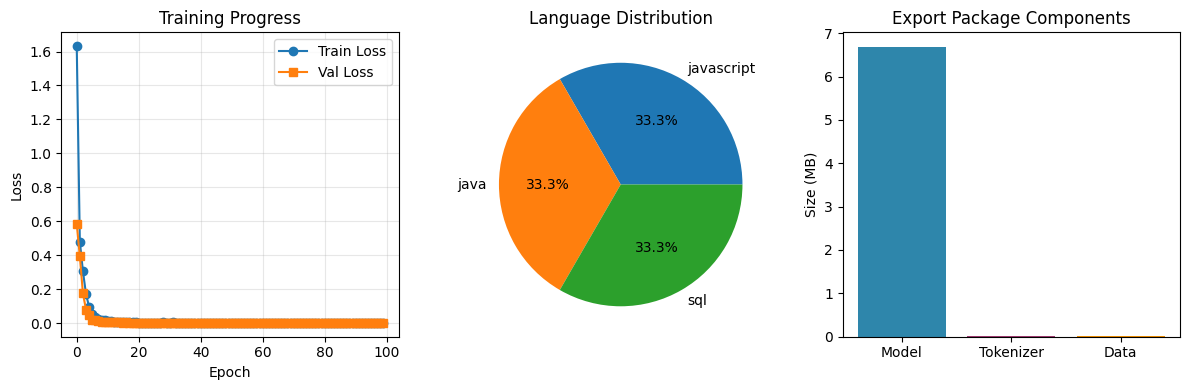

In [9]:
print("\n Generating training visualization...")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
languages = {}
for item in train_data:
    lang = item['language']
    languages[lang] = languages.get(lang, 0) + 1
plt.pie(languages.values(), labels=languages.keys(), autopct='%1.1f%%')
plt.title('Language Distribution')

plt.subplot(1, 3, 3)
sizes = {
    'Model': os.path.getsize(model_path) / 1024 / 1024,
    'Tokenizer': os.path.getsize(tokenizer_path) / 1024 / 1024,
    'Data': os.path.getsize(samples_path) / 1024 / 1024
}
plt.bar(sizes.keys(), sizes.values(), color=['#2E86AB', '#A23B72', '#F18F01'])
plt.ylabel('Size (MB)')
plt.title('Export Package Components')

plt.tight_layout()
plt.savefig(os.path.join(export_dir, 'training_summary.png'), dpi=150)
plt.show()

## Summary

In [11]:
print("\n" + "=" * 60)
print(" CODEBRIDGE MODEL TRAINING COMPLETE!")
print("=" * 60)

print("\n Training Summary:")
print(f"  Model Type: SimpleTransformer")
print(f"  Parameters: {config['parameters']:,}")
print(f"  Training Samples: {len(train_data)}")
print(f"  Languages: JavaScript, Java, SQL")
print(f"  Final Val Loss: {config['final_val_loss']:.4f}")
print(f"  Export Size: {os.path.getsize(zip_name) / 1024 / 1024:.2f} MB")


 CODEBRIDGE MODEL TRAINING COMPLETE!

 Training Summary:
  Model Type: SimpleTransformer
  Parameters: 1,748,486
  Training Samples: 3000
  Languages: JavaScript, Java, SQL
  Final Val Loss: 0.0027
  Export Size: 6.30 MB
